# Generate checkerboard pattern with 8x8 squares, and sine sweep from 100 Hz to 2000 Hz over 5 seconds.

In [ ]:
import numpy as np
import cv2
from scipy.signal import chirp 
from scipy.io.wavfile import write

# Image: Checkerboard
def generate_checkerboard(size=256, squares=8):
    block = np.kron([[1, 0] * (squares // 2), [0, 1] * (squares // 2)] * (squares // 2),
                    np.ones((size//squares, size//squares)))
    cv2.imwrite('Data/checkerboard.png', (block * 255).astype(np.uint8))

# Audio: Sine sweep
def generate_sine_sweep(f0=100, f1=2000, duration=5, fs=44100):
    t = np.linspace(0, duration, int(fs * duration))
    y = chirp(t, f0=f0, f1=f1, t1=duration, method='linear')
    write('Data/sine_sweep.wav', fs, (y * 32767).astype(np.int16))

generate_checkerboard(size=256, squares=8)
generate_sine_sweep(f0=100, f1=2000, duration=5, fs=44100)

# Perform multidimensional signal analysis including Fourier transform, filtering, and visualization.

## Image

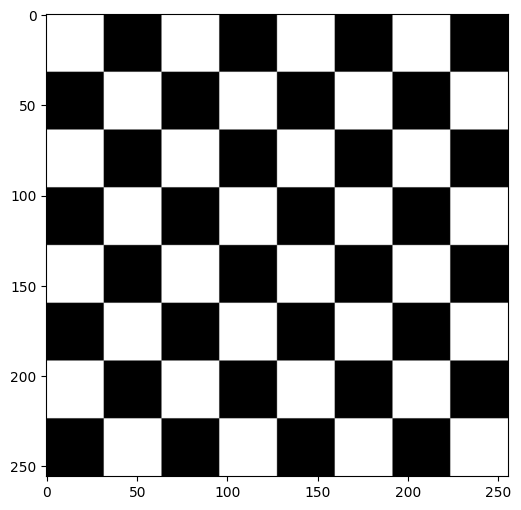

In [4]:
import cv2
from matplotlib import pyplot as plt

path1 = r"C:\Users\USER098\Documents\GitHub\Digital_singal_processing\L7\Data\checkerboard.png"

image = cv2.imread(path1, cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(6,6))
plt.imshow(image, cmap='gray')
plt.show()

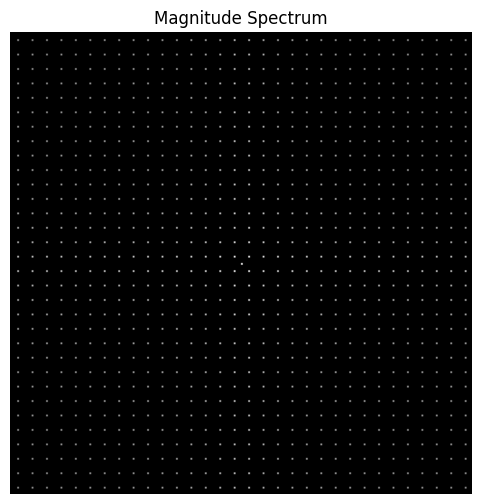

In [9]:
import numpy as np
import cv2
from matplotlib import pyplot as plt

path1 = r"C:\Users\USER098\Documents\GitHub\Digital_singal_processing\L7\Data\checkerboard.png"

image = cv2.imread(path1, cv2.IMREAD_GRAYSCALE)

# Compute 2D FFT
f = np.fft.fft2(image)
fshift = np.fft.fftshift(f) 

# Compute magnitude spectrum
magnitude_spectrum = 20 * np.log(np.abs(fshift) + 1)

plt.figure(figsize=(6,6))
plt.imshow(magnitude_spectrum, cmap='gray')
plt.title('Magnitude Spectrum')
plt.axis('off')
plt.show()

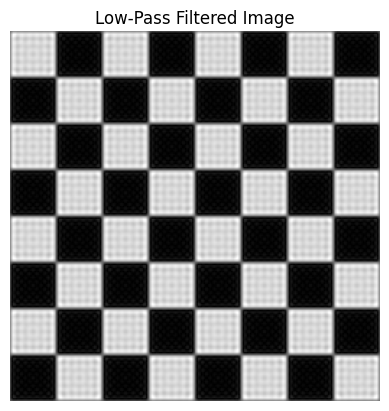

In [3]:
rows, cols = image.shape
crow, ccol = rows // 2 , cols // 2

# Create a low-pass filter mask (circle in the center)
mask_lp = np.zeros((rows, cols), np.uint8)
r = 50  # Radius
cv2.circle(mask_lp, (ccol, crow), r, 1, thickness=-1)

# Create high-pass mask as complement
mask_hp = 1 - mask_lp

# Apply the masks
fshift_lp = fshift * mask_lp
fshift_hp = fshift * mask_hp

# Inverse shift and IFFT for low-pass
f_ishift_lp = np.fft.ifftshift(fshift_lp)
img_back_lp = np.fft.ifft2(f_ishift_lp)
img_back_lp = np.abs(img_back_lp)

# Display the result
plt.imshow(img_back_lp, cmap='gray')
plt.title('Low-Pass Filtered Image')
plt.axis('off')
plt.show()

## Sound

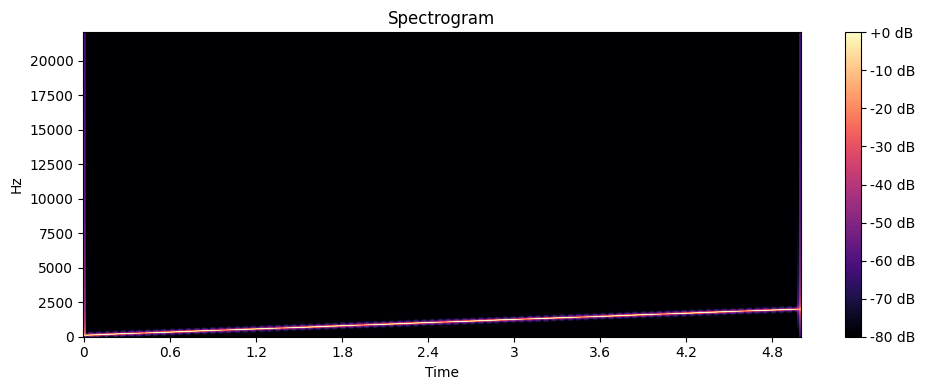

In [5]:
import numpy as np
import cv2
from matplotlib import pyplot as plt
import librosa
import librosa.display

path2 = r"C:\Users\USER098\Documents\GitHub\Digital_singal_processing\L7\Data\sine_sweep.wav"

# Load audio file
y, sr = librosa.load(path2, sr=None)

# Compute STFT
D = librosa.stft(y)
S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)

# Display spectrogram
plt.figure(figsize=(10, 4))
librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='hz', cmap='magma')
plt.colorbar(format='%+2.0f dB')
plt.title('Spectrogram')
plt.tight_layout()
plt.show()

# Compare time and frequency domain representations.

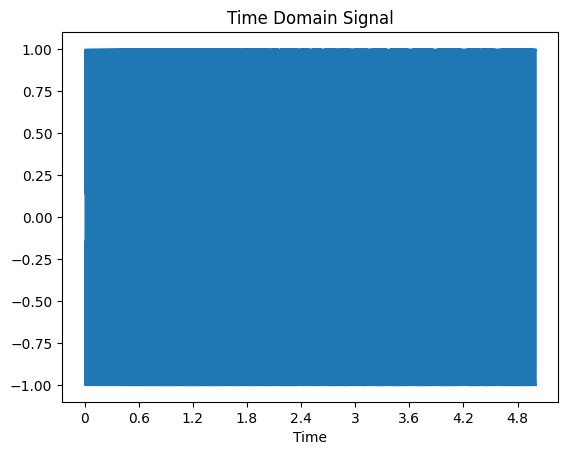

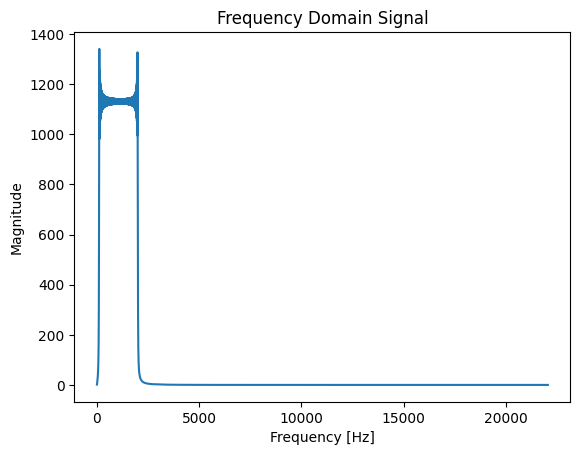

In [6]:
# Plot waveform (time domain)
plt.figure()
librosa.display.waveshow(y, sr=sr)
plt.title('Time Domain Signal')

# Plot magnitude spectrum (frequency domain)
Y = np.fft.fft(y)
freqs = np.fft.fftfreq(len(Y), 1/sr)
plt.figure()
plt.plot(freqs[:len(freqs)//2], np.abs(Y[:len(Y)//2]))
plt.title('Frequency Domain Signal')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Magnitude')
plt.show()